# Detect Spam Emails

 ## Importing Needed Libraries 

In [1]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import string

## Loading Dataset

In [2]:
df = pd.read_csv("spam.csv",encoding='latin-1' ) 

In [3]:
df

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN
...,...,...,...,...,...
5567,spam,This is the 2nd time we have tried 2 contact u...,NaN,NaN,NaN
5568,ham,Will Ì_ b going to esplanade fr home?,NaN,NaN,NaN
5569,ham,"Pity, * was in mood for that. So...any other s...",NaN,NaN,NaN
5570,ham,The guy did some bitching but I acted like i'd...,NaN,NaN,NaN


## Exploratory Data Analysis 

In [4]:
df.shape

(5572, 5)

In [5]:
df.columns.tolist()

['v1', 'v2', 'Unnamed: 2', 'Unnamed: 3', 'Unnamed: 4']

In [6]:
df.head()

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN


In [7]:
df.tail()

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
5567,spam,This is the 2nd time we have tried 2 contact u...,NaN,NaN,NaN
5568,ham,Will Ì_ b going to esplanade fr home?,NaN,NaN,NaN
5569,ham,"Pity, * was in mood for that. So...any other s...",NaN,NaN,NaN
5570,ham,The guy did some bitching but I acted like i'd...,NaN,NaN,NaN
5571,ham,Rofl. Its true to its name,NaN,NaN,NaN


In [8]:
df.sample(5)

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
2977,ham,Yar lor... Keep raining non stop... Or u wan 2...,NaN,NaN,NaN
4947,spam,"Hi this is Amy, we will be sending you a free ...",NaN,NaN,NaN
630,ham,Please dont say like that. Hi hi hi,NaN,NaN,NaN
4714,ham,S:)8 min to go for lunch:),NaN,NaN,NaN
527,ham,Yes! How is a pretty lady like you single?,NaN,NaN,NaN


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   v1          5572 non-null   object
 1   v2          5572 non-null   object
 2   Unnamed: 2  50 non-null     object
 3   Unnamed: 3  12 non-null     object
 4   Unnamed: 4  6 non-null      object
dtypes: object(5)
memory usage: 217.8+ KB


In [10]:
df.describe()

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
count,5572,5572,50,12,6
unique,2,5169,43,10,5
top,ham,"Sorry, I'll call later","bt not his girlfrnd... G o o d n i g h t . . .@""","MK17 92H. 450Ppw 16""","GNT:-)"""
freq,4825,30,3,2,2


In [11]:
df.isna().sum()

v1               0
v2               0
Unnamed: 2    5522
Unnamed: 3    5560
Unnamed: 4    5566
dtype: int64

In [12]:
df.nunique()

v1               2
v2            5169
Unnamed: 2      43
Unnamed: 3      10
Unnamed: 4       5
dtype: int64

In [13]:
df.duplicated().sum()

np.int64(403)

### Data cleaning

In [14]:
df= df.drop_duplicates()

In [15]:
df.duplicated().sum()

np.int64(0)

In [16]:
df=df.drop(columns=['Unnamed: 2','Unnamed: 3','Unnamed: 4'])

In [17]:
df.isna().sum()

v1    0
v2    0
dtype: int64

In [18]:
df=df.rename(columns={'v1':'label' ,
                      'v2':'message'})

In [19]:
df

,label,message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."
...,...,...
5567,spam,This is the 2nd time we have tried 2 contact u...
5568,ham,Will Ì_ b going to esplanade fr home?
5569,ham,"Pity, * was in mood for that. So...any other s..."
5570,ham,The guy did some bitching but I acted like i'd...


In [20]:
df['clean_msg'] = df['message'].apply(lambda s: s.lower())

In [21]:
df['clean_msg'] = df['clean_msg'].apply(lambda s: s.translate(str.maketrans('', '',string.punctuation)))

In [22]:
import re
def removeNums(msg):
    return re.sub(r'\d+', '', msg)
df['clean_msg'] = df['clean_msg'].apply(removeNums)    
df.head()

,label,message,clean_msg
0,ham,"Go until jurong point, crazy.. Available only ...",go until jurong point crazy available only in ...
1,ham,Ok lar... Joking wif u oni...,ok lar joking wif u oni
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,free entry in a wkly comp to win fa cup final...
3,ham,U dun say so early hor... U c already then say...,u dun say so early hor u c already then say
4,ham,"Nah I don't think he goes to usf, he lives aro...",nah i dont think he goes to usf he lives aroun...


In [23]:
import nltk
nltk.download('stopwords')
from nltk.corpus import stopwords

print(stopwords.words('english')[:20])

['a', 'about', 'above', 'after', 'again', 'against', 'ain', 'all', 'am', 'an', 'and', 'any', 'are', 'aren', "aren't", 'as', 'at', 'be', 'because', 'been']


[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\habib\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [24]:
def removeStopwords (msg): 
    words = msg.split()
    clean = []
    for word in words:
        if word not in stopwords.words('english'):
            clean.append(word)
    return " ".join(clean)

In [25]:
df['clean_msg'] = df['clean_msg'].apply(removeStopwords)

### Data Visualization

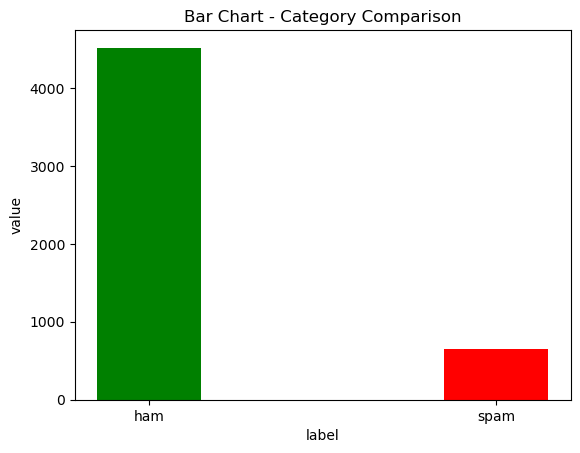

In [26]:
categories = ["ham","spam"]
values =df['label'].value_counts()
plt.bar(categories, values, width=0.3,color=('green','red'))
plt.title('Bar Chart - Category Comparison' )
plt.xlabel('label')
plt.ylabel('value')
plt.show()

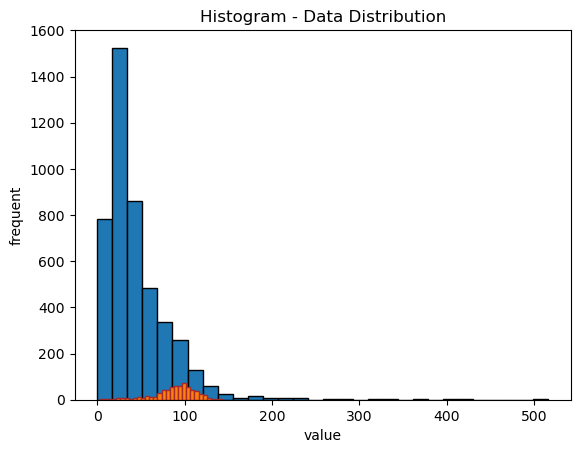

In [27]:
df['msg_length']= df['clean_msg'].apply(len)
ham_msgs =df[df['label']=='ham']
spam_msgs =df[df['label']=='spam']
ham = ham_msgs['msg_length']
spam = spam_msgs['msg_length']

plt.hist(ham, bins=30,edgecolor="black")
plt.title('Histogram - Data Distribution')
plt.xlabel('value')
plt.ylabel('frequent')

plt.hist(spam, bins=30,edgecolor="brown")
plt.xlabel('value')
plt.ylabel('frequent')
plt.show()

In [28]:
from wordcloud import WordCloud

In [29]:
spam_txt=" ".join(spam_msgs['clean_msg'])

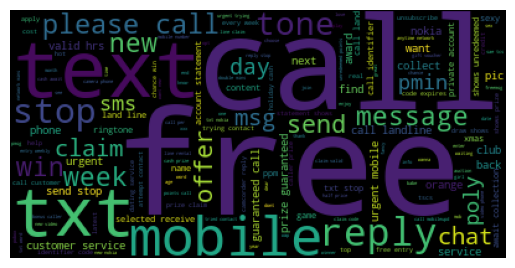

In [30]:
wordCloud = WordCloud(min_word_length=3, random_state=42).generate(spam_txt)
plt.imshow(wordCloud)
plt.axis('off')
plt.show()

## Feature Engineering

### TF-IDF

In [31]:
from sklearn.feature_extraction.text import TfidfVectorizer
vectorizer = TfidfVectorizer()
X = vectorizer.fit_transform(df['clean_msg'])
print (X.shape)

(5169, 8449)


In [32]:
y=df['label'].map({'ham':0 , 'spam':1})
print (y.unique())

[0 1]


## Data spliting (Train/Test) 


In [33]:
from sklearn.model_selection import train_test_split
X_train , X_test, y_train , y_test = train_test_split(X, y , test_size=0.3 , random_state=42 )


In [34]:
print(X_train.shape, X_test.shape)

(3618, 8449) (1551, 8449)


## Modeling

In [35]:
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score , classification_report , confusion_matrix

In [36]:
nb = MultinomialNB()
nb.fit(X_train , y_train)
y_pred = nb.predict(X_test)
print ("NB Accuracy:  ", accuracy_score(y_test,y_pred))
print(classification_report(y_test,y_pred))

NB Accuracy:   0.9529335912314636
              precision    recall  f1-score   support

           0       0.95      1.00      0.97      1331
           1       1.00      0.67      0.80       220

    accuracy                           0.95      1551
   macro avg       0.97      0.83      0.89      1551
weighted avg       0.96      0.95      0.95      1551



In [37]:
cm = confusion_matrix(y_test,y_pred)

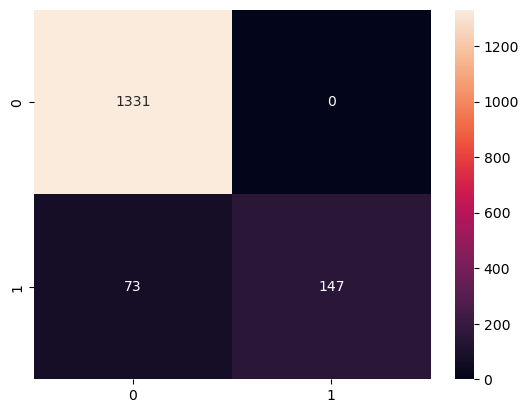

In [41]:
sns.heatmap(cm, annot=True,fmt='d')
plt.xlabel =('Predicted')
plt.ylabel =('Actual')
plt.show()

In [42]:
import pickle

with open('model.pkl', 'wb') as f:
    pickle.dump(nb, f)

with open('vectorizer.pkl', 'wb') as f:
    pickle.dump(vectorizer, f)

In [1]:
import os
print(os.getcwd())

C:\Users\habib\MLprojects\DetectSpamEmails
